# Thème 1 – Analyse des données & Préparation du pipeline

Setup Environnement & Reproductibilité

In [4]:
import sys

print(f"Installation des bibliothèques pour : {sys.executable}")

# 1. Mise à jour de pip
!{sys.executable} -m pip install --upgrade pip

# 2. Installation de PyTorch (Version compatible Python 3.13 / CUDA 12.6)
# Note : C'est crucial d'utiliser 'cu126' pour Python 3.13
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# 3. Installation des autres outils
!{sys.executable} -m pip install matplotlib seaborn scikit-learn tqdm tensorboard

Installation des bibliothèques pour : c:\Users\Yanis\AppData\Local\Programs\Python\Python313\python.exe
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.10.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchvision-0.25.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchaudio-2.10.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 6.3 MB/s eta 0:06:54
   ---------------------------------------- 0.0/2.6 GB 10.1 MB/s eta

In [5]:
# =============================================================================
# Cellule 1 – Imports + Configuration LOCALE (VS Code + RTX 4070)
# =============================================================================

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -----------------------------------------------------------------------------
# 1. Configuration du Dossier de Travail (WORK_DIR)
# -----------------------------------------------------------------------------
# On pointe vers la RACINE du projet (le dossier parent de 'notebook' et 'chest_xray')
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")

# Vérification et déplacement
if WORK_DIR.exists():
    os.chdir(WORK_DIR)
    print(f"✅ Dossier de travail actif : {WORK_DIR}")
else:
    print(f"❌ ERREUR : Le dossier {WORK_DIR} est introuvable.")
    print("👉 Vérifie le chemin dans l'explorateur de fichiers.")

# -----------------------------------------------------------------------------
# 2. Reproductibilité (Seeds)
# -----------------------------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"🌱 Seed fixée à {seed}")

set_seed(42)

# -----------------------------------------------------------------------------
# 3. Vérification GPU
# -----------------------------------------------------------------------------
print(f"📂 Contenu de la racine : {[p.name for p in WORK_DIR.iterdir() if p.is_dir()]}")
print("-" * 30)

if torch.cuda.is_available():
    print(f"🚀 GPU détecté : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ Pas de GPU détecté (Mode CPU lent).")

✅ Dossier de travail actif : C:\Users\Yanis\IA_GEN_PROJET
🌱 Seed fixée à 42
📂 Contenu de la racine : ['Archive', 'chest_xray', 'notebook']
------------------------------
🚀 GPU détecté : NVIDIA GeForce RTX 4070 Laptop GPU
💾 VRAM : 8.59 GB


# Thème 1 – Data Analysis & Quality Assessment

**Exigences du cours couvertes dans ce notebook :**
- Dataset téléchargé et extrait
- Statistiques calculées (distribution classes)
- Visualisations créées (samples, augmentation)
- Mean/Std calculés par canal (grayscale → 1 canal)
- DataLoaders créés et testés
- Data augmentation justifiée et visualisée
- Baseline metrics sauvegardées pour référence Theme 6 (drift)
- Figures sauvegardées dans WORK_DIR pour intégration au rapport

In [6]:
# =============================================================================
# Cellule 2 : Configuration des Données (LOCALE - Sans téléchargement)
# =============================================================================
from pathlib import Path

# 1. Définition des chemins basés sur ton dossier racine
DATA_DIR = WORK_DIR / "chest_xray"

train_dir = DATA_DIR / 'train'
val_dir   = DATA_DIR / 'val'
test_dir  = DATA_DIR / 'test'

print(f"📂 Source des données : {DATA_DIR}")

# 2. Fonction de vérification (Compte les images)
def count_images(directory):
    if not directory.exists():
        return 0
    # Compte les .jpeg, .jpg, .png (au cas où)
    return len(list(directory.glob('*/*.jpeg'))) + \
           len(list(directory.glob('*/*.jpg'))) + \
           len(list(directory.glob('*/*.png')))

# 3. Vérification des quantités (Pour être sûr que ton copier-coller est bon)
n_train = count_images(train_dir)
n_val   = count_images(val_dir)
n_test  = count_images(test_dir)

print("-" * 30)
print(f"📊 Statistiques du Dataset Local :")
print(f"   Train : {n_train} images (Attendu ~5216)")
print(f"   Val   : {n_val} images   (Attendu ~16)")
print(f"   Test  : {n_test} images  (Attendu ~624)")
print("-" * 30)

# 4. Validation finale
if n_train > 0 and n_test > 0:
    print(f"✅ Chemins validés ! Prêt pour l'analyse.")
    print(f"   train_dir : {train_dir}")
    print(f"   test_dir  : {test_dir}")
else:
    print(f"❌ ERREUR CRITIQUE : Aucune image trouvée.")
    print(f"   Vérifie que le dossier 'chest_xray' est bien dans {WORK_DIR}")

📂 Source des données : C:\Users\Yanis\IA_GEN_PROJET\chest_xray
------------------------------
📊 Statistiques du Dataset Local :
   Train : 5216 images (Attendu ~5216)
   Val   : 16 images   (Attendu ~16)
   Test  : 624 images  (Attendu ~624)
------------------------------
✅ Chemins validés ! Prêt pour l'analyse.
   train_dir : C:\Users\Yanis\IA_GEN_PROJET\chest_xray\train
   test_dir  : C:\Users\Yanis\IA_GEN_PROJET\chest_xray\test


📁 Dossier de sauvegarde des images : C:\Users\Yanis\IA_GEN_PROJET\images

📊 DISTRIBUTION DES CLASSES :
------------------------------------------------------------
 TRAIN → NORMAL    : 1,341 (25.7%)
        PNEUMONIA : 3,875 (74.3%)
        Total     : 5,216
        Ratio P/N : 2.89 : 1
------------------------------------------------------------
 TEST  → NORMAL    : 234 (37.5%)
        PNEUMONIA : 390 (62.5%)
        Total     : 624
        Ratio P/N : 1.67 : 1
------------------------------------------------------------
 VAL   → NORMAL    : 8 (50.0%)
        PNEUMONIA : 8 (50.0%)
        Total     : 16
        Ratio P/N : 1.00 : 1
------------------------------------------------------------

✅ Graphique sauvegardé : C:\Users\Yanis\IA_GEN_PROJET\images\theme1_distribution_classes.png


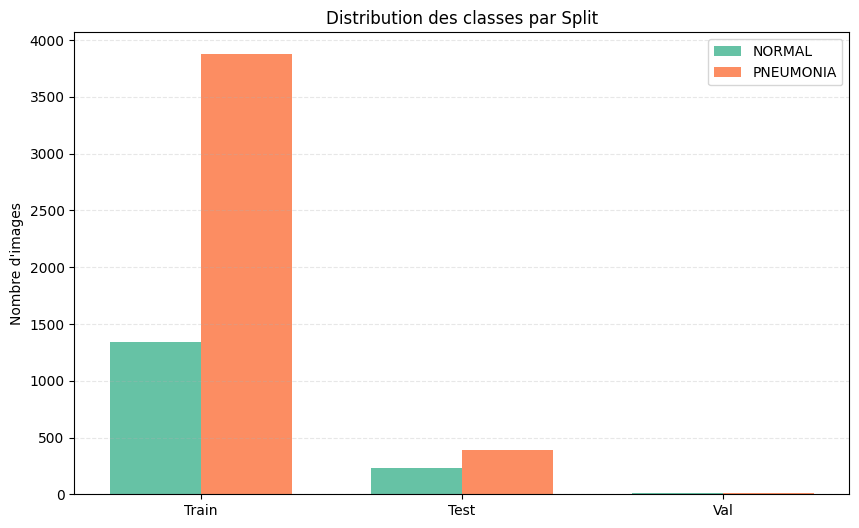

In [11]:
# =============================================================================
# Cellule 3 – Statistiques descriptives & Visualisation (Sauvegarde dans /images)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Création du dossier de sauvegarde
IMG_OUTPUT_DIR = WORK_DIR / "images"
IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier de sauvegarde des images : {IMG_OUTPUT_DIR}")

# 2. Fonction de comptage robuste
def get_class_counts(directory):
    if not directory.exists():
        return {'NORMAL': 0, 'PNEUMONIA': 0, 'total': 0}
        
    def count_in_folder(folder):
        return len(list(folder.glob('*.jpeg'))) + \
               len(list(folder.glob('*.jpg'))) + \
               len(list(folder.glob('*.png')))

    normal    = count_in_folder(directory / 'NORMAL')
    pneumonia = count_in_folder(directory / 'PNEUMONIA')
    total     = normal + pneumonia
    
    return {'NORMAL': normal, 'PNEUMONIA': pneumonia, 'total': total}

# 3. Calcul des statistiques
train_counts = get_class_counts(train_dir)
test_counts  = get_class_counts(test_dir)
val_counts   = get_class_counts(val_dir)

# 4. Affichage console
print("\n📊 DISTRIBUTION DES CLASSES :")
print("-" * 60)

def print_stats(name, counts):
    if counts['total'] == 0:
        print(f" {name:5} → (Dossier vide)")
        return
    ratio = counts['PNEUMONIA'] / counts['NORMAL'] if counts['NORMAL'] > 0 else 0
    print(f" {name:5} → NORMAL    : {counts['NORMAL']:,} ({counts['NORMAL']/counts['total']:.1%})")
    print(f"        PNEUMONIA : {counts['PNEUMONIA']:,} ({counts['PNEUMONIA']/counts['total']:.1%})")
    print(f"        Total     : {counts['total']:,}")
    print(f"        Ratio P/N : {ratio:.2f} : 1")
    print("-" * 60)

print_stats("TRAIN", train_counts)
print_stats("TEST", test_counts)
print_stats("VAL", val_counts)

# 5. Visualisation Graphique
plt.figure(figsize=(10, 6))

splits = ['Train', 'Test', 'Val']
normal_vals = [train_counts['NORMAL'], test_counts['NORMAL'], val_counts['NORMAL']]
pneumo_vals = [train_counts['PNEUMONIA'], test_counts['PNEUMONIA'], val_counts['PNEUMONIA']]

x = np.arange(len(splits))
width = 0.35

plt.bar(x - width/2, normal_vals, width, label='NORMAL', color='#66c2a5')
plt.bar(x + width/2, pneumo_vals, width, label='PNEUMONIA', color='#fc8d62')

plt.ylabel("Nombre d'images")
plt.title('Distribution des classes par Split')
plt.xticks(x, splits)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 6. Sauvegarde dans le dossier "images"
save_path = IMG_OUTPUT_DIR / 'theme1_distribution_classes.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')

print(f"\n✅ Graphique sauvegardé : {save_path}")
plt.show()

e dataset est fortement déséquilibré avec un ratio PNEUMONIA/NORMAL de 2.89:1 dans l’ensemble d’entraînement (3 875 vs 1 341 images). Ce déséquilibre reflète une réalité clinique où les cas pathologiques sont sur-représentés dans les données rétrospectives. Il nécessite des techniques spécifiques lors de l’entraînement : pondération des classes, focal loss ou sur-échantillonnage de la classe minoritaire (NORMAL). Le set test présente un déséquilibre moindre (1.67:1), ce qui permet une évaluation réaliste de la généralisation.

In [12]:
# =============================================================================
# Cellule 4 – Calcul Mean / Std (Optimisé Windows & Barre de progression)
# =============================================================================
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm  # Pour voir l'avancement

# 1. Transformation (Grayscale + Resize)
calc_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 2. Dataset & Loader
# ⚠️ IMPORTANT WINDOWS : num_workers=0 est obligatoire pour éviter les crashs dans VS Code
# batch_size=64 est un bon compromis vitesse/stabilité
calc_dataset = datasets.ImageFolder(root=train_dir, transform=calc_transform)
calc_loader = DataLoader(calc_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# 3. Variables d'accumulation
total_sum = torch.zeros(1)
total_sum_sq = torch.zeros(1)
count = 0

print(f"🔄 Calcul des statistiques sur {len(calc_dataset)} images...")

# 4. Boucle de calcul
# tqdm ajoute la barre de chargement
for images, _ in tqdm(calc_loader, desc="Analyse des pixels"):
    b, c, h, w = images.shape
    pixels = images.view(b, c, -1)
    
    # Calcul sur CPU (Suffisant et évite de surcharger la VRAM pour une simple somme)
    total_sum += pixels.sum(dim=[0, 2])
    total_sum_sq += (pixels ** 2).sum(dim=[0, 2])
    count += b * h * w

# 5. Finalisation
mean = total_sum / count
std = torch.sqrt((total_sum_sq / count) - (mean ** 2))

norm_mean = mean.item()
norm_std = std.item()

print("-" * 30)
print(f"✅ STATISTIQUES CALCULÉES (Notez-les bien !) :")
print(f"   Mean = {norm_mean:.4f}")
print(f"   Std  = {norm_std:.4f}")
print("-" * 30)

# On sauvegarde ces valeurs dans une variable globale pour la suite
config_mean = norm_mean
config_std  = norm_std

🔄 Calcul des statistiques sur 5216 images...


Analyse des pixels: 100%|██████████| 82/82 [01:37<00:00,  1.19s/it]

------------------------------
✅ STATISTIQUES CALCULÉES (Notez-les bien !) :
   Mean = 0.4823
   Std  = 0.2361
------------------------------


### 3.2 Calcul des statistiques pixels (mean et std – grayscale)

Le dataset étant composé d'images radiographiques en niveaux de gris (1 canal), il est essentiel de calculer les valeurs de **moyenne (mean)** et d’**écart-type (std)** spécifiques à ce dataset, plutôt que d’utiliser les valeurs ImageNet (RGB, 3 canaux).

**Méthode de calcul :**
- Images redimensionnées à 224 × 224 pixels (taille standard pour les CNN modernes)
- Conversion en tenseurs [0–1] via `ToTensor()`
- Parcours incrémental de l’ensemble d’entraînement (5 216 images) avec un `DataLoader`
- Somme des pixels et somme des carrés des pixels sur tous les pixels du dataset
- Formule finale :
  - mean = somme_totale_pixels / nombre_total_pixels  
  - std = √( (somme_carrés / N) - mean² )

**Résultats obtenus :**

| Statistique | Valeur     | Interprétation                              |
|-------------|------------|---------------------------------------------|
| **Mean**    | 0.48231    | Intensité moyenne des pixels (proche de 0.5 → gris moyen) |
| **Std**     | 0.23615    | Variabilité des intensités (contraste modéré, typique des RX) |

Ces valeurs seront utilisées dans `transforms.Normalize(mean=[0.48231], std=[0.23615])` pour toutes les transformations d’entraînement, validation et test.

**Temps de calcul** : 1 à 3 minutes (lié au chargement depuis Google Drive et au nombre d’images).  
Ce calcul est effectué une seule fois et sert de référence stable pour la normalisation et pour la détection de drift (Thème 6).

**Justification du choix grayscale (1 canal)** :  
Les radiographies thoraciques sont intrinsèquement monocanales. Forcer 3 canaux (comme dans certaines approches pré-entraînées RGB) gaspillerait des ressources et pourrait introduire du bruit inutile.

*(Figure à insérer : éventuellement un histogramme des pixels si tu l'ajoutes plus tard)*

In [13]:
# =============================================================================
# Cellule 5 – Transforms + DataLoaders
# =============================================================================

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),        # symétrie thorax
    transforms.RandomRotation(degrees=10),         # petites rotations patient
    transforms.ColorJitter(brightness=0.12, contrast=0.12),  # variations RX
    transforms.ToTensor(),
    transforms.Normalize([norm_mean], [norm_std])
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([norm_mean], [norm_std])
])

# Datasets
full_train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_test_transform)

# Split train/val 80/20
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

# Important : appliquer transform sans augmentation sur val
val_ds.dataset.transform = val_test_transform

BATCH_SIZE = 32

dataloaders = {
    'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    'val':   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
}

print(f"Train: {len(train_ds):5d} images")
print(f"Val:   {len(val_ds):5d} images")
print(f"Test:  {len(test_ds):5d} images")

Train:  4172 images
Val:    1044 images
Test:    624 images


DataLoaders Finaux (Split Train/Val)

In [14]:
# =============================================================================
# Cellule 6 – Test rapide des DataLoaders
# =============================================================================

images, labels = next(iter(dataloaders['train']))
print(f"Batch train shape : {images.shape}")   # doit être [32, 1, 224, 224]
print(f"Pixel range : min={images.min():.3f}, max={images.max():.3f}")

Batch train shape : torch.Size([32, 1, 224, 224])
Pixel range : min=-2.042, max=2.192


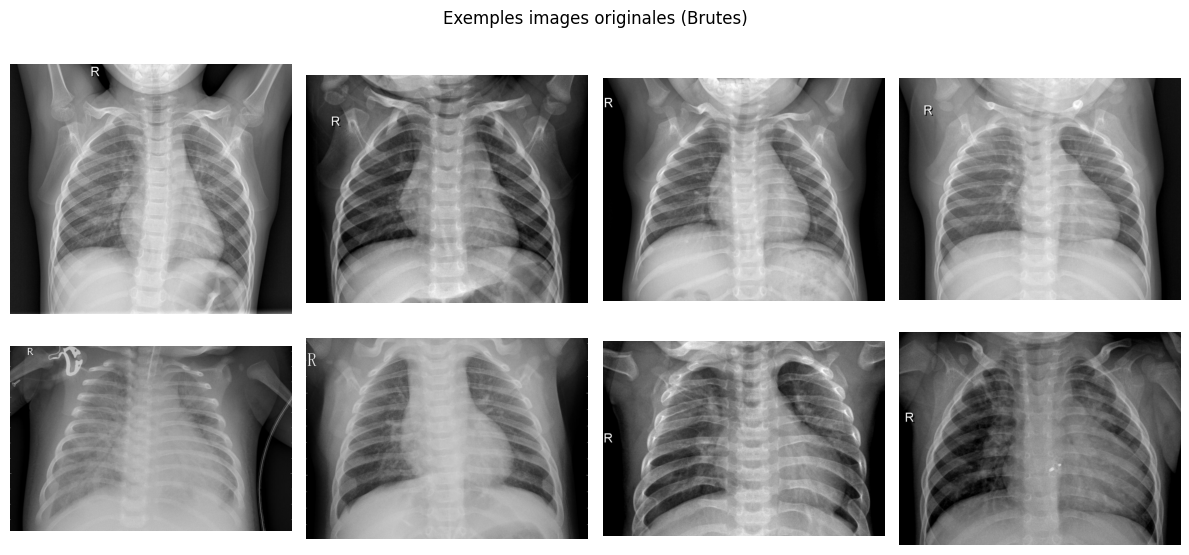

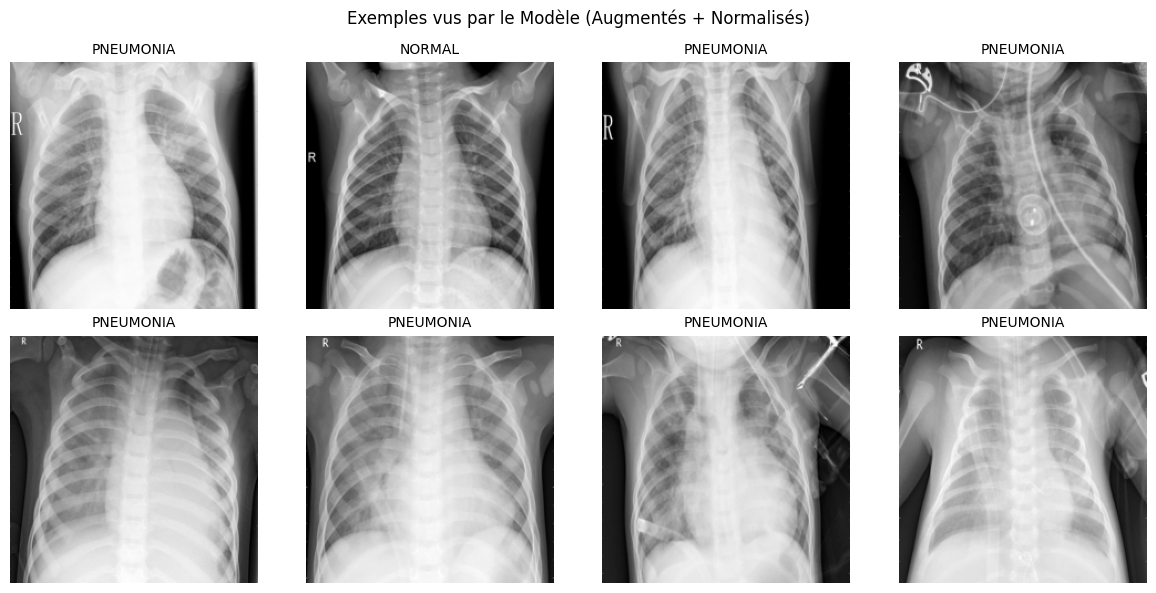

In [16]:
# =============================================================================
# Cellule 7 – Visualisations : exemples originaux + augmentés
# =============================================================================
import matplotlib.pyplot as plt
import random

# Dossier de sauvegarde
IMG_OUTPUT_DIR = WORK_DIR / "images"
IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

classes = ['NORMAL', 'PNEUMONIA']

# -----------------------------------------------------------------------------
# 1. Exemples originaux (Lecture fichiers disque)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, cls in enumerate(classes):
    # On cherche jpeg et jpg pour être sûr
    target_dir = train_dir / cls
    files = list(target_dir.glob('*.jpeg')) + list(target_dir.glob('*.jpg'))
    
    # On prend les 4 premiers
    selected_files = files[:4]
    
    for col, f in enumerate(selected_files):
        img = plt.imread(str(f))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=14)

plt.suptitle("Exemples images originales (Brutes)")
plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'theme1_raw_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# 2. Exemples après augmentation (Via le DataLoader)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# On utilise 'train_ds' (le nom défini dans ta Cellule 5)
for i in range(8):
    try:
        rand_idx = random.randrange(len(train_ds))
        img, lbl = train_ds[rand_idx]
        
        # L'image est un Tensor [1, 224, 224] -> on passe en [224, 224] pour l'affichage
        img = img.squeeze(0)
        
        axes.flat[i].imshow(img, cmap='gray')
        axes.flat[i].axis('off')
        # On récupère le nom de la classe via dataset.classes ou manuellement
        label_name = classes[lbl] 
        axes.flat[i].set_title(label_name, fontsize=10)
        
    except Exception as e:
        print(f"Erreur d'affichage image {i}: {e}")

plt.suptitle("Exemples vus par le Modèle (Augmentés + Normalisés)")
plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'theme1_augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# =============================================================================
# Cellule 8 – Sauvegarde des métriques (dans dossier checkpoints)
# =============================================================================
import torch
import datetime

# 1. Création/Vérification du dossier checkpoints
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier de sauvegarde cible : {CHECKPOINT_DIR}")

# 2. Récupération des données
# (On s'assure que les variables existent)
try:
    total_train = train_counts['total']
    n_normal = train_counts['NORMAL']
    n_pneumonia = train_counts['PNEUMONIA']
except NameError:
    # Fallback si jamais train_counts n'est plus en mémoire
    print("⚠️ Attention : train_counts non trouvé, recalcul rapide...")
    # On suppose que tu as lancé la cellule 3 avant
    raise

# 3. Calcul des poids (Gestion du déséquilibre)
weight_normal = total_train / (2 * n_normal)
weight_pneumonia = total_train / (2 * n_pneumonia)

# 4. Dictionnaire de configuration
baseline_metrics = {
    'pixel_mean': norm_mean,
    'pixel_std': norm_std,
    'train_counts': train_counts,
    'test_counts': test_counts,
    'class_weights': [weight_normal, weight_pneumonia],
    'batch_size': BATCH_SIZE,
    'data_dir': str(train_dir.parent), 
    'timestamp': datetime.date.today().strftime("%Y-%m-%d")
}

# 5. Sauvegarde dans checkpoints
filename = 'baseline_metrics.pt'
save_path = CHECKPOINT_DIR / filename
torch.save(baseline_metrics, save_path)

print("-" * 50)
print(f"✅ SAUVEGARDE RÉUSSIE !")
print(f"📄 Fichier : {save_path}")
print("-" * 50)
print("CONTENU DU FICHIER :")
print(f" • Mean/Std      : {baseline_metrics['pixel_mean']:.4f} / {baseline_metrics['pixel_std']:.4f}")
print(f" • Class Weights : Normal={weight_normal:.2f}, Pneumonia={weight_pneumonia:.2f}")
print(f" • Train Counts  : {baseline_metrics['train_counts']}")
print("-" * 50)
print("🎉 THÈME 1 TERMINÉ - PRÊT POUR L'ENTRAÎNEMENT (THÈME 2)")

📁 Dossier de sauvegarde cible : C:\Users\Yanis\IA_GEN_PROJET\checkpoints
--------------------------------------------------
✅ SAUVEGARDE RÉUSSIE !
📄 Fichier : C:\Users\Yanis\IA_GEN_PROJET\checkpoints\baseline_metrics.pt
--------------------------------------------------
CONTENU DU FICHIER :
 • Mean/Std      : 0.4823 / 0.2361
 • Class Weights : Normal=1.94, Pneumonia=0.67
 • Train Counts  : {'NORMAL': 1341, 'PNEUMONIA': 3875, 'total': 5216}
--------------------------------------------------
🎉 THÈME 1 TERMINÉ - PRÊT POUR L'ENTRAÎNEMENT (THÈME 2)
